In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from xgboost import XGBClassifier
import optuna

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e6


- spectral_type (tipo espectral) é uma classificação astronômica que agrupa as estrelas com base na temperatura da sua superfície e nas linhas de absorção do seu espectro de luz. A sequência oficial, da estrela mais quente para a mais fria, é memorizada pela clássica frase "Oh, Be A Fine Girl/Guy, Kiss Me": O, B, A, F, G, K, M.

- O termo ugriz (geralmente com apóstrofos: \(u', g', r', i', z'\)) designa um sistema de cinco filtros ópticos padronizados usados em telescópios, especialmente no Sloan Digital Sky Survey (SDSS). Cada letra isola uma faixa específica do espectro eletromagnético:
    - u: Ultravioleta (~355 nm)
    - g: Verde (green) (~470 nm)
    - r: Vermelho (red) (~615 nm)
    - i: Infravermelho (~750 nm)
    - z: Infravermelho distante (~890 nm)

- Redshift (ou desvio para o vermelho) é o estiramento das ondas de luz de objetos distantes causado pela expansão do universo. Como a luz viaja longas distâncias, ela se desloca para o lado vermelho do espectro. É uma medida direta da distância e da velocidade de afastamento de uma galáxia ou estrela

In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
classes = df_train['class'].unique()

le = LabelEncoder()
le.fit(df_train['class'])
df_train['class'] = le.transform(df_train['class'])


df = pd.concat([df_train,df_test], axis=0, sort=False)

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 824782 entries, 0 to 247434
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 824782 non-null  int64  
 1   alpha              824782 non-null  float64
 2   delta              824782 non-null  float64
 3   u                  824782 non-null  float64
 4   g                  824782 non-null  float64
 5   r                  824782 non-null  float64
 6   i                  824782 non-null  float64
 7   z                  824782 non-null  float64
 8   redshift           824782 non-null  float64
 9   spectral_type      824782 non-null  str    
 10  galaxy_population  824782 non-null  str    
 11  class              577347 non-null  float64
dtypes: float64(9), int64(1), str(2)
memory usage: 92.1 MB


In [5]:
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,0.0
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,0.0
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,1.0
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,0.0
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,0.0


In [6]:
df.describe()

,id,alpha,delta,u,g,r,i,z,redshift,class
count,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,824782.000000,577347.000000
mean,412390.500000,181.539859,21.840427,22.441969,21.008043,19.963663,19.379796,19.041740,0.723629,0.489465
std,238094.199199,96.234085,18.932900,2.018406,1.796388,1.649559,1.580605,1.585187,0.810224,0.732431
min,0.000000,0.010959,-17.966988,-0.139225,13.374549,10.390731,10.034180,10.632025,-0.009970,0.000000
25%,206195.250000,132.094915,2.489501,20.977437,19.865342,18.824152,18.308940,17.974107,0.181672,0.000000
50%,412390.500000,188.638826,21.466811,22.570080,21.468151,20.431239,19.631842,19.190919,0.497840,0.000000
75%,618585.750000,231.810960,36.995129,23.869337,22.293241,21.164551,20.611005,20.163769,0.881655,1.000000
max,824781.000000,359.999810,79.170436,28.253263,27.620208,25.291984,27.910853,26.826867,7.010780,2.000000


In [7]:
object_cols = df.select_dtypes(include=['str']).columns
object_cols

Index(['spectral_type', 'galaxy_population'], dtype='str')

In [8]:
for col in object_cols:
    print(f'{col} - {df[col].unique()}')

spectral_type - <ArrowStringArray>
['M', 'O/B', 'G/K', 'A/F']
Length: 4, dtype: str
galaxy_population - <ArrowStringArray>
['Red_Sequence', 'Blue_Cloud']
Length: 2, dtype: str


<Axes: xlabel='class', ylabel='spectral_type'>

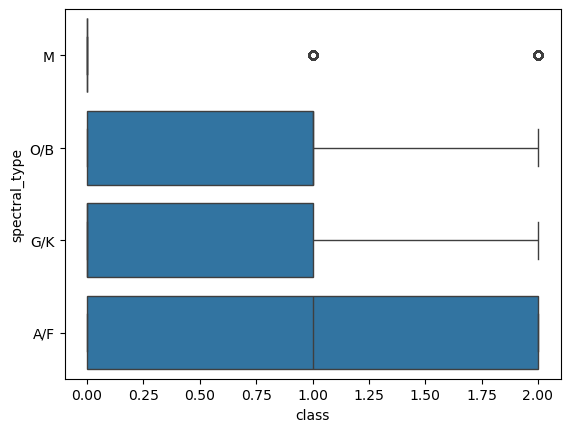

In [9]:
sns.boxplot(df,x='class',y='spectral_type')

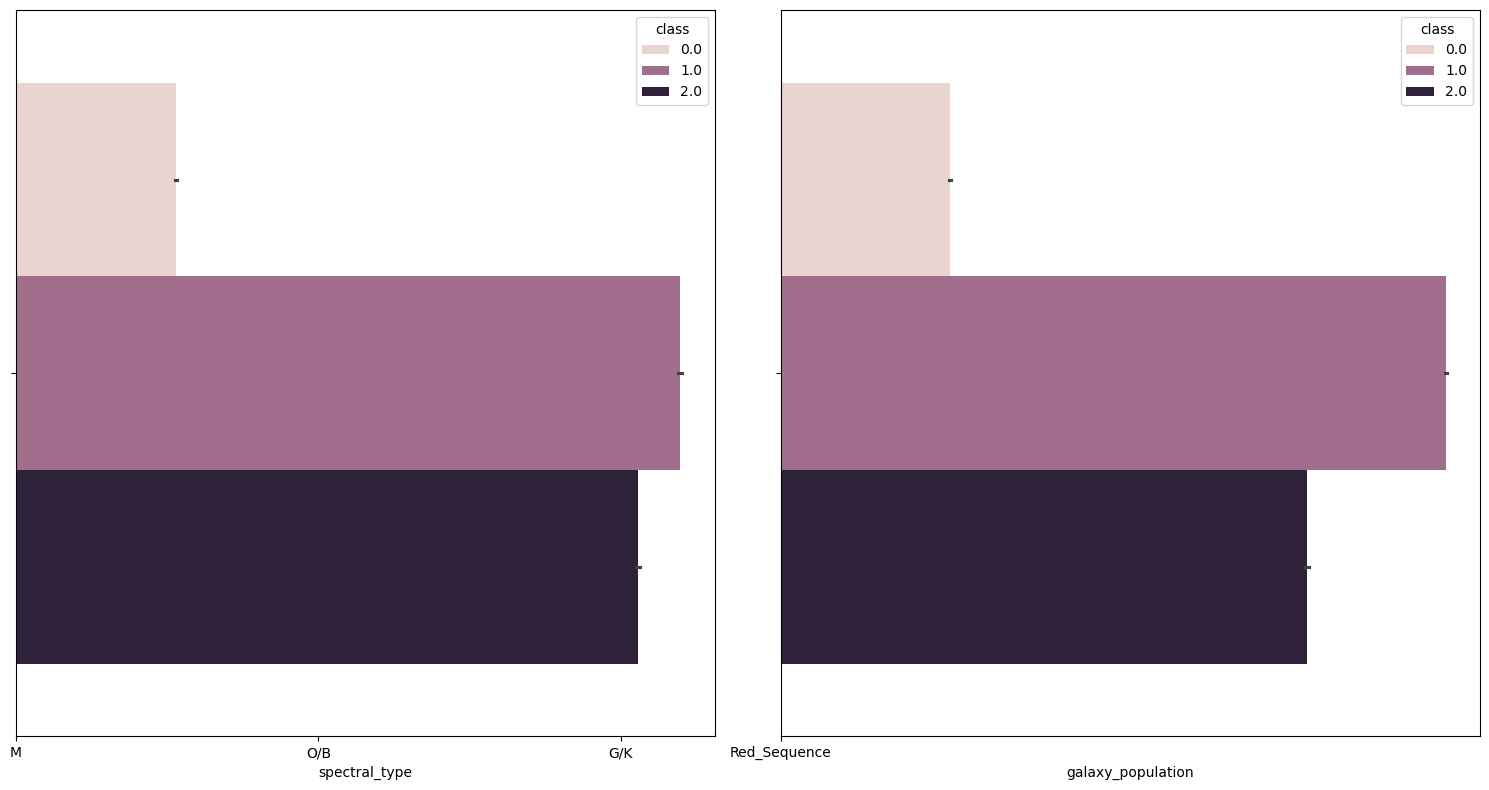

In [10]:
fig, ax = plt.subplots(1,2, figsize=(15,8))

sns.barplot(df,x='spectral_type',hue='class',ax=ax[0])
sns.barplot(df,x='galaxy_population',hue='class',ax=ax[1])

plt.tight_layout()

<Axes: >

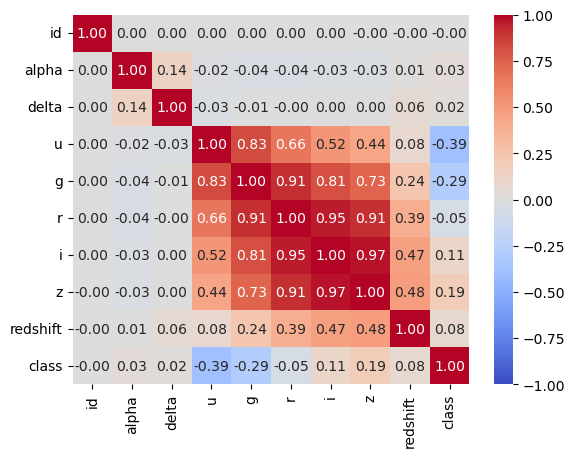

In [11]:
numeric_features = df.select_dtypes(include=['number']).columns

corr_mtx = df[numeric_features].corr()

sns.heatmap(
    corr_mtx,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)

In [12]:
corr_mtx['class'].sort_values(ascending=False)

class       1.000000
z           0.190467
i           0.107635
redshift    0.077758
alpha       0.033585
delta       0.017359
id         -0.000874
r          -0.049845
g          -0.285010
u          -0.385667
Name: class, dtype: float64

In [13]:
df['class'] = df['class'].fillna(0)

In [14]:
df['class'].isna().sum()

np.int64(0)

In [15]:
ids = df_test['id']
cols_to_remove = ['id']
df = df.drop(columns=cols_to_remove)

numeric = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
cols_to_onehot = ['spectral_type', 'galaxy_population']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False),cols_to_onehot)
    ],
    remainder='passthrough'
)

df_processed = preprocess.fit_transform(df)
names = preprocess.get_feature_names_out()

df = pd.DataFrame(df_processed, columns=names)



In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 824782 entries, 0 to 824781
Data columns (total 15 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   num__alpha                           824782 non-null  float64
 1   num__delta                           824782 non-null  float64
 2   num__u                               824782 non-null  float64
 3   num__g                               824782 non-null  float64
 4   num__r                               824782 non-null  float64
 5   num__i                               824782 non-null  float64
 6   num__z                               824782 non-null  float64
 7   num__redshift                        824782 non-null  float64
 8   cat__spectral_type_A/F               824782 non-null  float64
 9   cat__spectral_type_G/K               824782 non-null  float64
 10  cat__spectral_type_M                 824782 non-null  float64
 11  cat__spectral_type_O/B  

In [17]:
df.head()

,num__alpha,num__delta,num__u,num__g,num__r,num__i,num__z,num__redshift,cat__spectral_type_A/F,cat__spectral_type_G/K,cat__spectral_type_M,cat__spectral_type_O/B,cat__galaxy_population_Blue_Cloud,cat__galaxy_population_Red_Sequence,remainder__class
0,-0.351285,-0.257814,1.501261,0.494056,0.239012,-0.077618,-0.265384,-0.388346,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.556468,0.554923,-0.824146,-1.069358,-1.440661,-1.362598,-1.422740,-0.698145,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.018156,0.713278,-0.696969,0.039571,0.732425,0.760996,0.956119,2.592053,0.0,0.0,0.0,1.0,1.0,0.0,1.0
3,0.460112,1.411776,0.427608,0.023766,-0.573432,-0.641614,-0.710824,-0.231455,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.412575,-0.131917,-0.366037,-0.855252,-1.048289,-0.936571,-0.899299,-0.207187,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [18]:
features_numeric = df.select_dtypes(include=['number']).columns
features_numeric

Index(['num__alpha', 'num__delta', 'num__u', 'num__g', 'num__r', 'num__i',
       'num__z', 'num__redshift', 'cat__spectral_type_A/F',
       'cat__spectral_type_G/K', 'cat__spectral_type_M',
       'cat__spectral_type_O/B', 'cat__galaxy_population_Blue_Cloud',
       'cat__galaxy_population_Red_Sequence', 'remainder__class'],
      dtype='str')

In [19]:
df['u_g'] = df['num__u'] - df['num__g']
df['g_r'] = df['num__g'] - df['num__r']
df['r_i'] = df['num__r'] - df['num__i']
df['i_z'] = df['num__i'] - df['num__z']
df['u_r'] = df['num__u'] - df['num__r']


In [20]:
training = df[:df_train.shape[0]]
testing = df[df_train.shape[0]:]

In [21]:
testing = testing.drop(columns='remainder__class')

In [22]:
X = training.drop(columns='remainder__class')
y = training['remainder__class']

In [23]:
# cluster_range = range(2, 11)
# cluster_sample_size = min(120000, len(X))
# X_cluster_sample = X.sample(n=cluster_sample_size, random_state=42)

# silhouette_scores = []

# for k in cluster_range:
#     km_tmp = KMeans(n_clusters=k, random_state=0, n_init="auto")
#     labels_tmp = km_tmp.fit_predict(X_cluster_sample)

#     score = silhouette_score(
#         X_cluster_sample,
#         labels_tmp,
#         sample_size=min(10000, len(X_cluster_sample)),
#         random_state=42,
#     )
#     silhouette_scores.append(score)
#     print(f"k={k} | silhouette={score:.4f}")

# best_n_clusters = list(cluster_range)[np.argmax(silhouette_scores)]
# print(f"\nMelhor numero de clusters (silhouette): {best_n_clusters}")

# plt.figure(figsize=(8, 4))
# plt.plot(list(cluster_range), silhouette_scores, marker="o")
# plt.xlabel("Numero de clusters (k)")
# plt.ylabel("Silhouette medio")
# plt.title("Analise de silhouette para KMeans")
# plt.grid(alpha=0.3)
# plt.show()
# Melhor resultado= 2

In [24]:

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto")
X['cluster'] = kmeans.fit_predict(X)

testing['cluster'] = kmeans.predict(testing)

In [25]:
X_train, X_temp, y_train ,y_temp = train_test_split(X,y, test_size=0.2, random_state=0,shuffle=True,stratify=y)
X_test, X_val, y_test ,y_val = train_test_split(X_temp,y_temp, test_size=0.5, random_state=0,shuffle=True,stratify=y_temp)

X_train.shape, X_test.shape, X_val.shape 

((461877, 20), (57735, 20), (57735, 20))

In [ ]:
# def objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "random_state": 42,
#         "eval_metric": "mlogloss",
#     }
#     model = XGBClassifier(**params)
#     score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy").mean()
#     return score

# study = optuna.create_study(
#     direction="maximize",
#     study_name="xgb_tuning",
# )

# study.optimize(objective, n_trials=30)
# print("Melhor score:", study.best_value)
# print("Melhores params:", study.best_params)

[I 2026-06-05 06:58:44,592] A new study created in memory with name: xgb_tuning
[I 2026-06-05 07:00:26,376] Trial 0 finished with value: 0.9667617136163956 and parameters: {'n_estimators': 1039, 'max_depth': 9, 'learning_rate': 0.06389394853982121, 'subsample': 0.9621953616612997, 'colsample_bytree': 0.8151200401732903}. Best is trial 0 with value: 0.9667617136163956.
[I 2026-06-05 07:00:48,359] Trial 1 finished with value: 0.9508895225352204 and parameters: {'n_estimators': 285, 'max_depth': 5, 'learning_rate': 0.01148105564048287, 'subsample': 0.8087873352071424, 'colsample_bytree': 0.6179238059708589}. Best is trial 0 with value: 0.9667617136163956.
[I 2026-06-05 07:01:46,110] Trial 2 finished with value: 0.9655406092964145 and parameters: {'n_estimators': 494, 'max_depth': 8, 'learning_rate': 0.17346555009711415, 'subsample': 0.637230636898609, 'colsample_bytree': 0.6005514749813153}. Best is trial 0 with value: 0.9667617136163956.
[I 2026-06-05 07:02:55,182] Trial 3 finished with 

Melhor score: 0.9667617136163956
Melhores params: {'n_estimators': 1039, 'max_depth': 9, 'learning_rate': 0.06389394853982121, 'subsample': 0.9621953616612997, 'colsample_bytree': 0.8151200401732903}


In [33]:
best_model = XGBClassifier(
    n_estimators = 1039, 
    max_depth= 9, 
    learning_rate= 0.06389394853982121, 
    subsample= 0.9621953616612997, 
    colsample_bytree= 0.8151200401732903,
    random_state=42,
    eval_metric="mlogloss"
)

best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

In [34]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98     37748
         1.0       0.97      0.96      0.96     11714
         2.0       0.93      0.93      0.93      8273

    accuracy                           0.97     57735
   macro avg       0.96      0.96      0.96     57735
weighted avg       0.97      0.97      0.97     57735



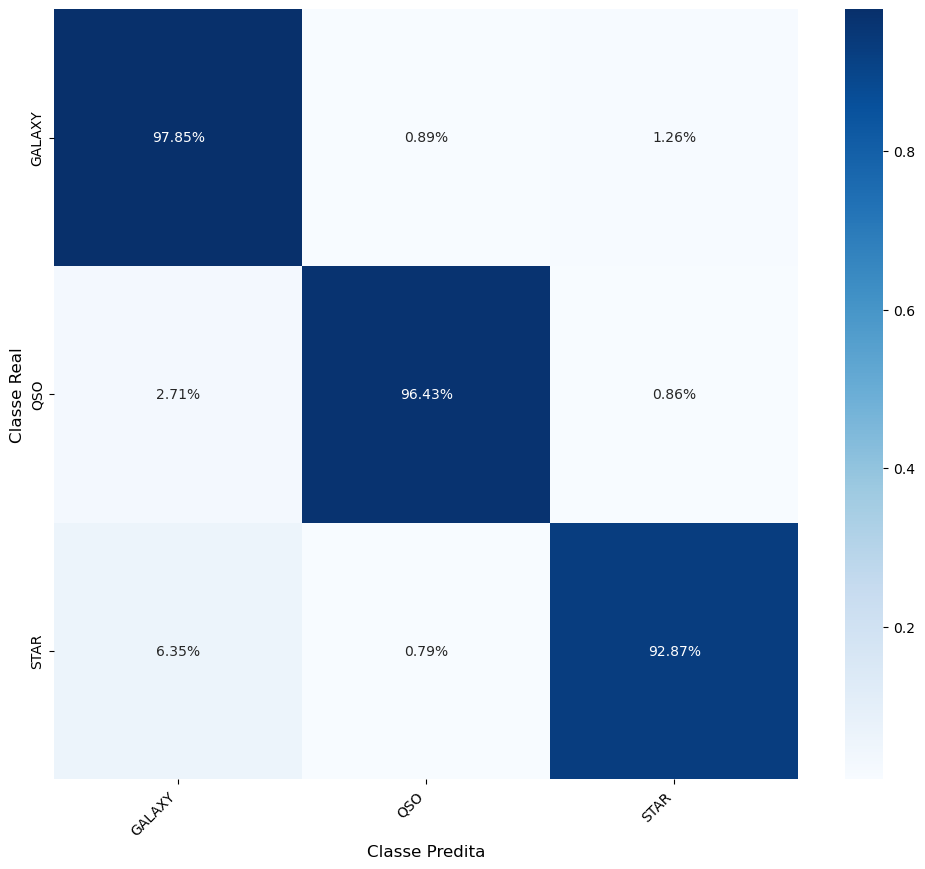

In [35]:
cm = confusion_matrix(y_test, preds, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=classes, 
            yticklabels=classes)

plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()


In [36]:
preds

array([0, 0, 0, ..., 0, 0, 0], shape=(57735,))

In [37]:
preds_final = best_model.predict(testing[X.columns])

preds_label = le.inverse_transform(preds_final)

df_final = pd.DataFrame({'id': ids, 'class': preds_label})
df_final.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [38]:
df_final.to_csv('submission.csv',index=False)

accuracy 0.97

cm: 
- GALAXY: 97.85

- QSO: 96.43

- STAR: 92.87